<a href="https://colab.research.google.com/github/MwamiEric/Data-Science-Projects/blob/main/Decision_Tree_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [ ]:
# To write a Python 2/3 compatible codebase, the first step is to add this line to the top of each module
from __future__ import division, print_function, unicode_literals

import numpy as np # Importing NumPy, a powerful library for numerical operations, especially with arrays.
import pandas as pd # Importing Pandas, essential for data manipulation and analysis, primarily with DataFrames.

# Setting a random seed (like a starting point for randomness) to ensure that any random operations
# (like splitting data or initializing weights) will produce the same results every time we run the code.
np.random.seed(42)

import matplotlib                    # Importing the entire Matplotlib library, the foundation for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt      # Importing the 'pyplot' module from Matplotlib and aliasing it as 'plt'. This module provides a MATLAB-like interface for plotting, making it easy to create various types of plots with just a few lines of code.

# Customizing global plot settings using Matplotlib's 'rcParams' to control the aesthetics of our visualizations.
# This ensures consistent styling across all your plots.
plt.rcParams['axes.labelsize']= 14      # Setting the font size for the x and y-axis labels to 14 points.
plt.rcParams['xtick.labelsize']= 12     # Setting the font size for the x-axis tick labels (the numbers/text next to the tick marks) to 12 points.
plt.rcParams['ytick.labelsize']= 12     # Setting the font size for the y-axis tick labels to 12 points.
plt.rcParams['xtick.color'] = 'red'     # Setting the color of the x-axis tick marks and their labels to red.
plt.rcParams['ytick.color'] = 'blue'    # Setting the color of the y-axis tick marks and their labels to blue.

# **Data Loading and Exploration**

In [ ]:
# Loading dataset from the specified CSV file into a Pandas DataFrame named 'dataset'.
dataset = pd.read_csv("/HW1_Data.csv")

#Start with knowing the number of records/rows and features/columns
print(f"Dataset Shape: {dataset.shape[0]} records, {dataset.shape[1]} features")

# Displaying the first few rows of your DataFrame.
print("First few rows to inspect dataset")
print(dataset.head())

#Basic Statistics from the dataset
print("Basic Statistics:")
print(dataset.describe())

# Checking for any missing values (NaN) in each column of your DataFrame.
# '.isna()' creates a boolean DataFrame where 'True' indicates a missing value.
# '.sum()' then counts the number of 'True' values (missing values) for each column.
print("Number of Missing values for each attribute:")
dataset.isna().sum()

# Analyze the target variable (churndep)
# Values count for 0 and 1 or not churn and churn respectively
print(f"\n\nTarget Variable Distribution (churndep):")
print(dataset['churndep'].value_counts())

# Target variable rate in whole dataset
print(f"\nChurn Rate: {dataset['churndep'].mean()*100:.2f}%")

#Class distribution in target variable
print(f"Class Distribution:")
print(f"  - No Churn (0): {(dataset['churndep']==0).sum()} ({(dataset['churndep']==0).mean()*100:.2f}%)")
print(f"  - Churn (1): {(dataset['churndep']==1).sum()} ({(dataset['churndep']==1).mean()*100:.2f}%)")

Dataset Shape: 31891 records, 12 features
First few rows to inspect dataset
   revenue  outcalls  incalls  months  eqpdays  webcap  marryyes  travel  \
0    83.53     20.00      1.0      31      745       1         0       0   
1    29.99      0.00      0.0      52     1441       0         0       0   
2    37.75      2.67      0.0      25      572       0         0       0   
3     5.25      0.00      0.0      45     1354       0         0       0   
4    42.71      8.67      0.0      27      224       1         0       0   

   pcown  creditcd  retcalls  churndep  
0      0         0         4         1  
1      1         1         3         1  
2      1         1         3         1  
3      0         0         2         1  
4      0         0         3         1  
Basic Statistics:
            revenue      outcalls       incalls        months       eqpdays  \
count  31891.000000  31891.000000  31891.000000  31891.000000  31891.000000   
mean      58.665179     24.951385      8.0652

# **Data Preparation**

In [ ]:
#Split data into features and target
x = dataset.drop('churndep', axis=1)
y = dataset['churndep']

# **Training and Visualizing a Decision Tree**


Training Set Size: 25512 records
Test Set Size: 6379 records

Training Set Churn Distribution:
  - No Churn: 12802 (50.18%)
  - Churn: 12710 (49.82%)


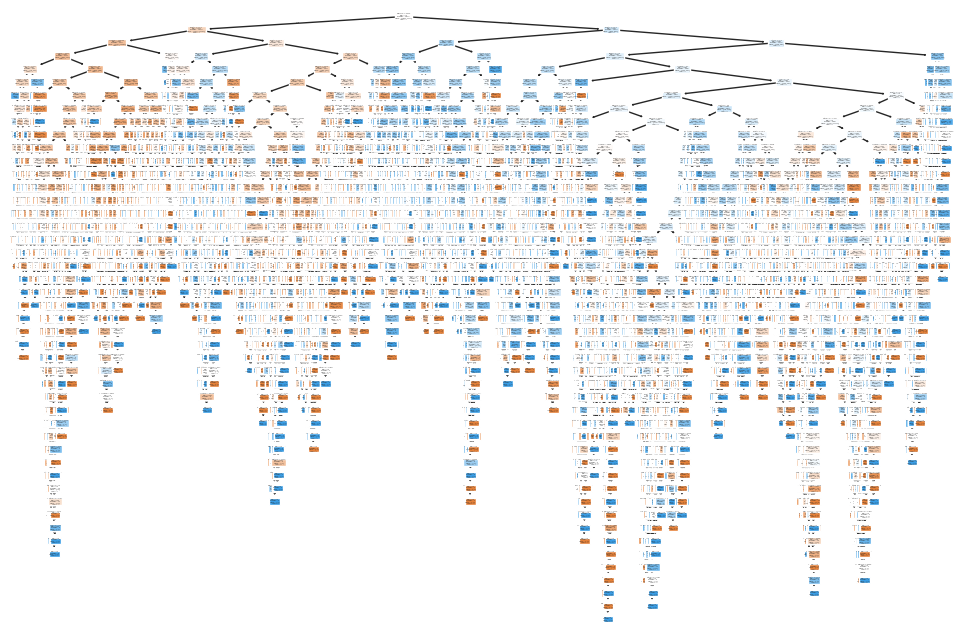

Training Accuracy: 99.98%
Accuracy: 0.5312744944348644
Confusion Matrix:
[[1715 1519]
 [1471 1674]]


In [ ]:
# Importing the DecisionTreeClassifier from scikit-learn. This is a machine learning algorithm used for classification tasks,
# capable of handling both binary and multi-class classification problems by creating a tree-like model of decisions.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import seaborn as sns     # Seaborn documentation can be found here https://seaborn.pydata.org/generated/seaborn.set.html
sns.set(color_codes=True) # Configure Seaborn's default aesthetic parameters in one step.
from scipy import stats   # Import stats package of scipy https://docs.scipy.org/doc/scipy/reference/stats.html#module-scipy.stats
                          # The stats module contains a large number of probability distributions, statistical functions, and statistical tests.


# Splitting the dataset into training and testing sets with 'x' contains the features (independent variables) and 'y' contains the target (dependent variable).
# test_size=0.2 means 20% of the data will be used for testing, and the remaining 80% for training.

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


#Let see the size of our training and testing dataset
print(f"\nTraining Set Size: {len(X_train)} records")
print(f"Test Set Size: {len(X_test)} records")
print(f"\nTraining Set Churn Distribution:")
print(f"  - No Churn: {(y_train==0).sum()} ({(y_train==0).mean()*100:.2f}%)")
print(f"  - Churn: {(y_train==1).sum()} ({(y_train==1).mean()*100:.2f}%)")

#Fit decsion tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)


#Plot the decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names = x.columns, class_names=['1','0'], filled=True)
plt.show()

# 1. Generate predictions on the training data
y_train_pred = dt_model.predict(X_train)

# 2. Compare true training labels to the predicted training labels
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

#Evaluate
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Testing Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)



In [ ]:
#Fit decsion tree model
dt_model = DecisionTreeClassifier(max_depth=3)   # Now we set the
dt_model.fit(X_train, y_train)


#Plot the decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names = x.columns, class_names=['1','0'], filled=True)
plt.show()

#Evaluate
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)